# LumenY 5.1 — Microstructure Feature Engineering (Cross Pairs)

Exact replica of  for **8 new cross pairs**.

**New Pairs:** EURJPY, GBPJPY, EURGBP, EURAUD, AUDJPY, CADJPY, CHFJPY, AUDNZD

**Output:**  (does NOT overwrite existing features_2)

Same 64 microstructure features, same computation pipeline.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.special import digamma
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../backend/data/raw')
PROCESSED_DIR = Path('../backend/data/processed')
FEATURES_DIR = Path('../backend/data/features_3')
FEATURES_DIR.mkdir(exist_ok=True)

PAIRS = ['EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD']
TRAIN_END = '2024-06-30'

print(f'Pairs: {PAIRS}')
print(f'Raw dir: {RAW_DIR} — exists: {RAW_DIR.exists()}')
print(f'Processed dir: {PROCESSED_DIR} — exists: {PROCESSED_DIR.exists()}')
print(f'Output dir: {FEATURES_DIR}')

Pairs: ['EURJPY', 'GBPJPY', 'EURGBP', 'EURAUD', 'AUDJPY', 'CADJPY', 'CHFJPY', 'AUDNZD']
Raw dir: ..\backend\data\raw — exists: True
Processed dir: ..\backend\data\processed — exists: True
Output dir: ..\backend\data\features_3


## 1. Feature Computation Functions

Each function takes 1-minute OHLCV data for a single hour and returns feature values.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# REALIZED VOLATILITY ESTIMATORS
# More efficient than close-to-close vol — use full OHLC microstructure.
# ═══════════════════════════════════════════════════════════════════════════════

def realized_vol_estimators(o, h, l, c):
    """Compute realized volatility estimators from 1-min OHLC within one hour."""
    n = len(o)
    if n < 5:
        return {k: np.nan for k in ['rv_close', 'rv_parkinson', 'rv_garman_klass',
                                     'rv_rogers_satchell', 'rv_yang_zhang', 'range_return_ratio']}
    
    log_ret = np.log(c[1:] / c[:-1])
    log_hl = np.log(h / l)
    log_co = np.log(c / o)
    log_ho = np.log(h / o)
    log_lo = np.log(l / o)
    log_hc = np.log(h / c)
    log_lc = np.log(l / c)
    
    # ── Close-to-close realized variance ──
    rv_close = np.sum(log_ret**2)
    
    # ── Parkinson (1980): uses high-low range ──
    rv_parkinson = np.sum(log_hl**2) / (4 * n * np.log(2))
    
    # ── Garman-Klass (1980): uses OHLC ──
    rv_gk = np.mean(0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2)
    
    # ── Rogers-Satchell (1991): drift-independent ──
    rv_rs = np.mean(log_ho * log_hc + log_lo * log_lc)
    
    # ── Yang-Zhang (2000): handles overnight jumps, most efficient ──
    log_oc = np.log(o[1:] / c[:-1])  # overnight returns
    n_oc = len(log_oc)
    if n_oc > 1:
        mu_oc = np.mean(log_oc)
        sigma_oc = np.sum((log_oc - mu_oc)**2) / (n_oc - 1)
        
        mu_co = np.mean(log_co)
        sigma_co = np.sum((log_co - mu_co)**2) / (n - 1)
        
        sigma_rs = np.mean(log_ho * log_hc + log_lo * log_lc)
        
        k = 0.34 / (1.34 + (n + 1) / (n - 1))
        rv_yz = sigma_oc + k * sigma_co + (1 - k) * sigma_rs
    else:
        rv_yz = rv_gk
    
    # ── Range-return ratio: how much of the range was "used" ──
    total_range = np.sum(log_hl)
    total_abs_ret = np.sum(np.abs(log_ret))
    range_return_ratio = total_abs_ret / total_range if total_range > 1e-15 else 1.0
    
    return {
        'rv_close': rv_close,
        'rv_parkinson': rv_parkinson,
        'rv_garman_klass': rv_gk,
        'rv_rogers_satchell': rv_rs,
        'rv_yang_zhang': rv_yz,
        'range_return_ratio': range_return_ratio,
    }

print('Realized volatility estimators defined.')

Realized volatility estimators defined.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# JUMP DETECTION — Barndorff-Nielsen & Shephard (2004)
# Separates continuous price variation from discrete jumps.
# ═══════════════════════════════════════════════════════════════════════════════

from math import lgamma

def jump_detection(returns):
    """Detect jumps using realized variance vs bipower variation."""
    n = len(returns)
    if n < 5:
        return {k: np.nan for k in ['rv', 'bv', 'jump_ratio', 'jump_z',
                                     'jump_intensity', 'jump_mean_size', 'jump_asymmetry']}
    
    # Realized variance
    rv = np.sum(returns**2)
    
    # Bipower variation — robust to jumps
    abs_r = np.abs(returns)
    bv = (np.pi / 2) * (n / (n - 1)) * np.sum(abs_r[1:] * abs_r[:-1])
    
    # Jump component
    jump = max(rv - bv, 0)
    jump_ratio = jump / rv if rv > 1e-20 else 0
    
    # Tri-power quarticity for jump test variance
    mu_43 = 2**(2/3) * np.exp(lgamma(7/6) - lgamma(1/2))
    if n >= 4:
        tpq = n * mu_43**(-3) * (n / (n-2)) * np.sum(
            abs_r[2:]**(4/3) * abs_r[1:-1]**(4/3) * abs_r[:-2]**(4/3)
        )
        v_const = np.pi**2/4 + np.pi - 5
        # Use max(tpq/bv**2 - 1, 0) formulation to avoid negative variance
        relative_qv = max(tpq / (bv**2) - 1, 0) if bv > 1e-20 else 0
        denom = np.sqrt(v_const * relative_qv / n) * bv if bv > 1e-20 else 0
        jump_z = (rv - bv) / denom if denom > 1e-20 else 0
        # Clamp to reasonable z-stat range
        jump_z = np.clip(jump_z, -10, 10)
    else:
        jump_z = 0
    
    # Individual jump detection: |r_i| > C * sqrt(BV/N)
    threshold = 3.0 * np.sqrt(max(bv / n, 1e-20))
    is_jump = np.abs(returns) > threshold
    n_jumps = is_jump.sum()
    jump_intensity = n_jumps / n
    
    if n_jumps > 0:
        jump_returns = returns[is_jump]
        jump_mean_size = np.mean(np.abs(jump_returns))
        n_pos = (jump_returns > 0).sum()
        n_neg = (jump_returns < 0).sum()
        jump_asymmetry = (n_pos - n_neg) / n_jumps
    else:
        jump_mean_size = 0
        jump_asymmetry = 0
    
    return {
        'rv': rv,
        'bv': bv,
        'jump_ratio': jump_ratio,
        'jump_z': jump_z,
        'jump_intensity': jump_intensity,
        'jump_mean_size': jump_mean_size,
        'jump_asymmetry': jump_asymmetry,
    }

print('Jump detection defined.')

Jump detection defined.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# ORDER FLOW — Kyle's Lambda, BVC, VPIN proxy, Amihud
# Adapted for forex OHLCV (no order book). Uses Bulk Volume Classification.
# ═══════════════════════════════════════════════════════════════════════════════

def order_flow_features(o, h, l, c, v, rolling_sigma=None):
    """Compute order flow features from 1-min OHLCV.
    rolling_sigma: trailing std of log returns for BVC normalization."""
    n = len(c)
    if n < 5:
        return {k: np.nan for k in ['buy_volume_frac', 'order_imbalance', 'order_imbalance_intensity',
                                     'kyle_lambda', 'kyle_lambda_r2', 'amihud_illiq',
                                     'volume_cv']}
    
    log_ret = np.log(c / o)  # intrabar returns
    
    # ── Bulk Volume Classification (Easley, Lopez de Prado, O'Hara 2012) ──
    if rolling_sigma is not None and rolling_sigma > 1e-10:
        sigma = rolling_sigma
    else:
        sigma = max(np.std(np.diff(np.log(c))), 1e-10)
    
    z_scores = log_ret / sigma
    v_buy = v * stats.norm.cdf(z_scores)
    v_sell = v - v_buy
    
    total_v = v.sum()
    if total_v < 1:
        total_v = 1
    
    buy_frac = v_buy.sum() / total_v
    oi = (v_buy.sum() - v_sell.sum()) / total_v  # normalized order imbalance
    
    # Order imbalance intensity (absolute, for VPIN-like measure)
    oi_intensity = np.abs(v_buy.sum() - v_sell.sum()) / total_v
    
    # ── Kyle's Lambda (price impact per unit signed flow) ──
    bar_returns = np.diff(np.log(c))
    signed_flow = np.sign(bar_returns) * np.sqrt(np.maximum(v[1:], 1))
    
    if len(bar_returns) > 3 and np.std(signed_flow) > 1e-10:
        slope, intercept, r_value, _, _ = stats.linregress(signed_flow, bar_returns)
        kyle_lambda = slope
        kyle_r2 = r_value**2
    else:
        kyle_lambda = 0
        kyle_r2 = 0
    
    # ── Amihud Illiquidity (price impact per unit volume) ──
    v_safe = np.maximum(v, 1)
    abs_ret = np.abs(np.diff(np.log(c)))
    amihud = np.mean(abs_ret / np.log1p(v_safe[1:]))
    
    # ── Volume irregularity (coefficient of variation) ──
    v_mean = v.mean()
    volume_cv = v.std() / v_mean if v_mean > 0 else 0
    
    return {
        'buy_volume_frac': buy_frac,
        'order_imbalance': oi,
        'order_imbalance_intensity': oi_intensity,
        'kyle_lambda': kyle_lambda,
        'kyle_lambda_r2': kyle_r2,
        'amihud_illiq': amihud,
        'volume_cv': volume_cv,
    }

print('Order flow features defined.')

Order flow features defined.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# INFORMATION THEORY — Entropy, KL divergence, non-Gaussianity
# Low entropy before breakouts. Fat tails signal regime change.
# ═══════════════════════════════════════════════════════════════════════════════

def information_theory_features(returns, volumes=None):
    """Compute entropy and distribution shape features."""
    n = len(returns)
    if n < 10:
        return {k: np.nan for k in ['entropy_returns', 'entropy_norm', 'jb_statistic',
                                     'entropy_volume_divergence', 'kl_proxy']}
    
    # ── Shannon entropy of returns (histogram method) ──
    # Use Freedman-Diaconis rule for bin width
    iqr = np.percentile(returns, 75) - np.percentile(returns, 25)
    if iqr > 0:
        bin_width = 2 * iqr * n**(-1/3)
        n_bins = max(int(np.ceil((returns.max() - returns.min()) / bin_width)), 5)
        n_bins = min(n_bins, 30)  # cap to avoid sparse bins
    else:
        n_bins = 10
    
    hist, _ = np.histogram(returns, bins=n_bins)
    p = hist / hist.sum()
    p = p[p > 0]
    entropy = -np.sum(p * np.log(p))
    entropy_norm = entropy / np.log(n_bins)  # normalized to [0, 1]
    
    # ── Jarque-Bera statistic (non-Gaussianity) ──
    s = stats.skew(returns)
    k = stats.kurtosis(returns, fisher=True)  # excess kurtosis
    jb = (n / 6) * (s**2 + (k**2) / 4)
    
    # ── KL divergence proxy ──
    # How far the return distribution is from Gaussian
    # Using normalized JB as a practical proxy
    kl_proxy = jb / n  # per-observation non-Gaussianity
    
    # ── Volume-weighted entropy divergence ──
    if volumes is not None and len(volumes) == n and volumes.sum() > 0:
        # Bin returns, weight by volume instead of count
        bin_edges = np.linspace(returns.min() - 1e-10, returns.max() + 1e-10, n_bins + 1)
        bin_idx = np.digitize(returns, bin_edges) - 1
        bin_idx = np.clip(bin_idx, 0, n_bins - 1)
        
        vol_per_bin = np.zeros(n_bins)
        for i in range(n):
            vol_per_bin[bin_idx[i]] += volumes[i]
        
        pv = vol_per_bin / vol_per_bin.sum()
        pv = pv[pv > 0]
        entropy_vol = -np.sum(pv * np.log(pv))
        entropy_vol_norm = entropy_vol / np.log(n_bins)
        
        # Divergence: if volume concentrates in specific return ranges, this is positive
        entropy_volume_divergence = entropy_norm - entropy_vol_norm
    else:
        entropy_volume_divergence = 0
    
    return {
        'entropy_returns': entropy,
        'entropy_norm': entropy_norm,
        'jb_statistic': jb,
        'entropy_volume_divergence': entropy_volume_divergence,
        'kl_proxy': kl_proxy,
    }

print('Information theory features defined.')

Information theory features defined.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# FRACTAL ANALYSIS — Hurst exponent & fractal dimension
# H > 0.5 = trending, H < 0.5 = mean-reverting, H = 0.5 = random walk
# ═══════════════════════════════════════════════════════════════════════════════

def hurst_rs(series, min_window=10):
    """Hurst exponent via Rescaled Range (R/S) method."""
    n = len(series)
    if n < 30:
        return np.nan
    
    # Window sizes: powers of 2 that fit in the data
    max_k = int(np.log2(n))
    window_sizes = [2**i for i in range(int(np.log2(min_window)), max_k + 1) if 2**i <= n // 2]
    
    if len(window_sizes) < 3:
        return np.nan
    
    rs_values = []
    for w in window_sizes:
        n_segments = n // w
        rs_list = []
        for seg in range(n_segments):
            chunk = series[seg*w:(seg+1)*w]
            m = chunk.mean()
            cumdev = np.cumsum(chunk - m)
            R = cumdev.max() - cumdev.min()
            S = chunk.std(ddof=1)
            if S > 1e-15:
                rs_list.append(R / S)
        if rs_list:
            rs_values.append((np.log(w), np.log(np.mean(rs_list))))
    
    if len(rs_values) < 3:
        return np.nan
    
    x = np.array([v[0] for v in rs_values])
    y = np.array([v[1] for v in rs_values])
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def fractal_dimension_higuchi(series, k_max=16):
    """Higuchi fractal dimension. D near 1 = smooth, D near 2 = noisy."""
    n = len(series)
    if n < 30:
        return np.nan
    
    k_values = [k for k in [1, 2, 4, 8, 16, 32] if k < n // 4]
    if len(k_values) < 3:
        return np.nan
    
    lk_values = []
    for k in k_values:
        lm_list = []
        for m in range(1, k + 1):
            indices = np.arange(m - 1, n, k)
            if len(indices) < 2:
                continue
            diffs = np.abs(np.diff(series[indices]))
            norm = (n - 1) / (len(diffs) * k * k)
            lm_list.append(diffs.sum() * norm)
        if lm_list:
            lk_values.append((np.log(1.0/k), np.log(np.mean(lm_list))))
    
    if len(lk_values) < 3:
        return np.nan
    
    x = np.array([v[0] for v in lk_values])
    y = np.array([v[1] for v in lk_values])
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope


def fractal_features(returns, prices):
    """Compute fractal dimension (per-hour Hurst removed — too few points, use hurst_6h)."""
    return {
        'fractal_dim': fractal_dimension_higuchi(prices),
    }

print('Fractal analysis features defined.')

Fractal analysis features defined.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# MARKET EFFICIENCY — Variance ratios, runs test, autocorrelation structure
# Detects whether microstructure is trending, mean-reverting, or random.
# ═══════════════════════════════════════════════════════════════════════════════

def market_efficiency_features(returns):
    """Compute market efficiency metrics from 1-min returns."""
    n = len(returns)
    if n < 15:
        return {k: np.nan for k in ['vr_5', 'vr_10', 'vr_z5', 'runs_z',
                                     'autocorr_1', 'autocorr_2', 'autocorr_5',
                                     'autocorr_decay_halflife', 'sum_abs_autocorr',
                                     'noise_to_signal']}
    
    # ── Variance Ratios ──
    # VR(q) > 1 = momentum, VR(q) < 1 = mean reversion
    rv1 = np.var(returns, ddof=1)
    
    def variance_ratio(r, q):
        if len(r) < q + 1 or rv1 < 1e-20:
            return 1.0, 0.0
        # q-period returns
        r_q = np.array([r[i:i+q].sum() for i in range(len(r) - q + 1)])
        vr = np.var(r_q, ddof=1) / (q * rv1)
        # Lo-MacKinlay z-stat
        z = (vr - 1) / np.sqrt(2 * (2*q - 1) * (q - 1) / (3 * q * n))
        return vr, z
    
    vr5, z5 = variance_ratio(returns, 5)
    vr10, _ = variance_ratio(returns, 10)
    
    # ── Runs Test ──
    signs = returns[returns != 0]
    if len(signs) > 5:
        pos = (signs > 0).astype(int)
        n_pos = pos.sum()
        n_neg = len(pos) - n_pos
        runs = 1 + np.sum(np.diff(pos) != 0)
        n_total = len(pos)
        
        if n_pos > 0 and n_neg > 0:
            e_runs = 1 + 2 * n_pos * n_neg / n_total
            v_runs = (2*n_pos*n_neg*(2*n_pos*n_neg - n_total)) / (n_total**2 * (n_total - 1))
            runs_z = (runs - e_runs) / np.sqrt(max(v_runs, 1e-20))
        else:
            runs_z = 0
    else:
        runs_z = 0
    
    # ── Autocorrelation at multiple lags ──
    def autocorr(r, lag):
        if len(r) <= lag + 1:
            return 0
        r_dm = r - r.mean()
        denom = np.sum(r_dm**2)
        if denom < 1e-20:
            return 0
        return np.sum(r_dm[lag:] * r_dm[:-lag]) / denom
    
    ac1 = autocorr(returns, 1)
    ac2 = autocorr(returns, 2)
    ac5 = autocorr(returns, 5)
    
    # ── Autocorrelation decay profile ──
    # Fit |rho(k)| ~ exp(-k/tau), half-life = tau * ln(2)
    lags = list(range(1, min(21, n//2)))
    abs_acs = [abs(autocorr(returns, k)) for k in lags]
    valid = [(k, ac) for k, ac in zip(lags, abs_acs) if ac > 1e-6]
    
    if len(valid) >= 3:
        x_fit = np.array([v[0] for v in valid])
        y_fit = np.log(np.array([v[1] for v in valid]))
        slope, _, _, _, _ = stats.linregress(x_fit, y_fit)
        tau = -1 / slope if slope < -0.01 else 100  # cap at 100
        halflife = tau * np.log(2)
    else:
        halflife = 0
    
    sum_abs_ac = sum(abs_acs)
    
    # ── Noise-to-signal ratio (Hansen-Lunde 2006) ──
    # Microstructure noise induces negative lag-1 autocorrelation
    noise_var = -np.mean(returns[:-1] * returns[1:])
    noise_var = max(noise_var, 0)  # clamp negative (trending market)
    bv_per_bar = np.mean(np.abs(returns[1:]) * np.abs(returns[:-1])) * (np.pi / 2)
    nsr = noise_var / bv_per_bar if bv_per_bar > 1e-20 else 0
    
    return {
        'vr_5': vr5,
        'vr_10': vr10,
        'vr_z5': z5,
        'runs_z': runs_z,
        'autocorr_1': ac1,
        'autocorr_2': ac2,
        'autocorr_5': ac5,
        'autocorr_decay_halflife': halflife,
        'sum_abs_autocorr': sum_abs_ac,
        'noise_to_signal': nsr,
    }

print('Market efficiency features defined.')

Market efficiency features defined.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# TAIL RISK & DISTRIBUTION SHAPE
# Realized skewness, kurtosis, tail ratios, Hill estimator
# ═══════════════════════════════════════════════════════════════════════════════

def tail_risk_features(returns):
    """Compute tail risk and distribution shape features."""
    n = len(returns)
    if n < 10:
        return {k: np.nan for k in ['realized_skew', 'realized_kurt',
                                     'tail_ratio_95_5', 'hill_tail_index']}
    
    rv = np.sum(returns**2)
    
    # Realized skewness (Neuberger 2012)
    if rv > 1e-20:
        rskew = (np.sqrt(n) * np.sum(returns**3)) / rv**1.5
        rkurt = (n * np.sum(returns**4)) / rv**2
    else:
        rskew = 0
        rkurt = 3
    
    # Tail ratio
    p95 = np.abs(np.percentile(returns, 95))
    p5 = np.abs(np.percentile(returns, 5))
    tail_ratio = p95 / p5 if p5 > 1e-15 else 1.0
    
    # Hill tail index — heavier tails = lower alpha
    abs_r = np.sort(np.abs(returns))[::-1]  # descending
    k = max(int(np.sqrt(n)), 3)
    if k < n and abs_r[k] > 1e-15:
        log_sum = np.sum(np.log(abs_r[:k] / abs_r[k]))
        if log_sum > 1e-10:
            hill = k / log_sum
            hill = min(hill, 20.0)  # cap at 20 — beyond that it's effectively Gaussian
        else:
            hill = np.nan
    else:
        hill = np.nan
    
    return {
        'realized_skew': rskew,
        'realized_kurt': rkurt,
        'tail_ratio_95_5': tail_ratio,
        'hill_tail_index': hill,
    }

print('Tail risk features defined.')

Tail risk features defined.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# PRICE ACCELERATION & MICRO MOMENTUM
# Second derivative of price, momentum shifts within the hour
# ═══════════════════════════════════════════════════════════════════════════════

def acceleration_features(c, returns):
    """Compute price acceleration and micro momentum features."""
    n = len(returns)
    if n < 10:
        return {k: np.nan for k in ['accel_mean', 'accel_std', 'accel_skew',
                                     'momentum_shift', 'ret_concentration',
                                     'vol_clustering_ac1']}
    
    # ── Price acceleration (second derivative) ──
    velocity = np.diff(c)
    if len(velocity) > 1:
        accel = np.diff(velocity)
        accel_mean = np.mean(accel)
        accel_std = np.std(accel)
        accel_skew = stats.skew(accel) if len(accel) > 3 else 0
    else:
        accel_mean = accel_std = accel_skew = 0
    
    # ── Momentum shift: last third vs first third ──
    third = n // 3
    if third > 0:
        ret_first = returns[:third].sum()
        ret_last = returns[-third:].sum()
        momentum_shift = ret_last - ret_first
    else:
        momentum_shift = 0
    
    # ── Return concentration: what fraction of total |return| comes from top 10% bars ──
    abs_ret = np.abs(returns)
    total_abs = abs_ret.sum()
    if total_abs > 1e-15:
        top_k = max(int(n * 0.1), 1)
        top_returns = np.sort(abs_ret)[-top_k:].sum()
        ret_concentration = top_returns / total_abs
    else:
        ret_concentration = 0
    
    # ── Volatility clustering: autocorrelation of squared returns ──
    r2 = returns**2
    if len(r2) > 2:
        r2_dm = r2 - r2.mean()
        denom = np.sum(r2_dm**2)
        if denom > 1e-20:
            vol_cluster_ac1 = np.sum(r2_dm[1:] * r2_dm[:-1]) / denom
        else:
            vol_cluster_ac1 = 0
    else:
        vol_cluster_ac1 = 0
    
    return {
        'accel_mean': accel_mean,
        'accel_std': accel_std,
        'accel_skew': accel_skew,
        'momentum_shift': momentum_shift,
        'ret_concentration': ret_concentration,
        'vol_clustering_ac1': vol_cluster_ac1,
    }

print('Acceleration features defined.')

Acceleration features defined.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CROSS-TIMEFRAME FEATURES
# Compare 1min vs 5min vs 15min behavior within same hour.
# ═══════════════════════════════════════════════════════════════════════════════

def cross_timeframe_features(returns_1m, returns_5m, returns_15m):
    """Compare microstructure across timeframes."""
    feat = {}
    
    rv_1m = np.sum(returns_1m**2) if len(returns_1m) > 0 else np.nan
    rv_5m = np.sum(returns_5m**2) if len(returns_5m) > 0 else np.nan
    rv_15m = np.sum(returns_15m**2) if len(returns_15m) > 0 else np.nan
    
    # ── Epps ratios: noise detection across timeframes ──
    # Higher ratio = more microstructure noise at fine scale
    # Clamp to [0, 50] — ratios beyond that are numerical artifacts from near-zero denominators
    def safe_ratio(num, den, cap=50.0):
        if den is not None and den > 1e-20:
            return min(num / den, cap)
        return np.nan
    
    feat['epps_1m_5m'] = safe_ratio(rv_1m, rv_5m)
    feat['epps_1m_15m'] = safe_ratio(rv_1m, rv_15m)
    feat['epps_5m_15m'] = safe_ratio(rv_5m, rv_15m)
    
    # ── Information acceleration: last half vs first half RV ──
    if len(returns_1m) >= 10:
        mid = len(returns_1m) // 2
        rv_first = np.sum(returns_1m[:mid]**2)
        rv_last = np.sum(returns_1m[mid:]**2)
        ratio = rv_last / rv_first if rv_first > 1e-20 else 1.0
        feat['info_accel'] = min(ratio, 50.0)  # cap extreme ratios
    else:
        feat['info_accel'] = np.nan
    
    # ── Volatility of volatility (sub-period vol variation) ──
    # Split hour into 6 ten-minute blocks
    if len(returns_1m) >= 30:
        block_size = len(returns_1m) // 6
        block_vols = []
        for i in range(6):
            block = returns_1m[i*block_size:(i+1)*block_size]
            if len(block) > 1:
                block_vols.append(np.std(block))
        if len(block_vols) > 1:
            mean_bv = np.mean(block_vols)
            feat['vol_of_vol'] = np.std(block_vols) / mean_bv if mean_bv > 1e-15 else 0
        else:
            feat['vol_of_vol'] = np.nan
    else:
        feat['vol_of_vol'] = np.nan
    
    # ── 5-min autocorrelation (different timescale signal) ──
    if len(returns_5m) > 3:
        r5_dm = returns_5m - returns_5m.mean()
        denom = np.sum(r5_dm**2)
        feat['autocorr_5m_lag1'] = np.sum(r5_dm[1:] * r5_dm[:-1]) / denom if denom > 1e-20 else 0
    else:
        feat['autocorr_5m_lag1'] = np.nan
    
    return feat

print('Cross-timeframe features defined.')

Cross-timeframe features defined.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# ROLLING / TRAILING WINDOW FEATURES
# Features that need multi-hour context (Hurst, VPIN, regime)
# Computed after the per-hour features, using trailing windows.
# ═══════════════════════════════════════════════════════════════════════════════

def compute_trailing_features(df_hourly, returns_1m_series):
    """Add trailing-window features that need multi-hour context.
    
    df_hourly: DataFrame with per-hour features (indexed by datetime)
    returns_1m_series: dict mapping hour_timestamp -> array of 1min returns
    """
    n = len(df_hourly)
    
    # ── Hurst exponent over trailing 6-hour window ──
    hurst_values = np.full(n, np.nan)
    fractal_values = np.full(n, np.nan)
    hours = df_hourly.index.tolist()
    
    for i in range(6, n):  # need at least 6 hours
        window_hours = hours[max(0, i-6):i]
        # Concatenate 1min returns from trailing 6 hours
        all_returns = []
        for h in window_hours:
            if h in returns_1m_series:
                all_returns.append(returns_1m_series[h])
        if all_returns:
            concat_ret = np.concatenate(all_returns)
            if len(concat_ret) >= 60:
                hurst_values[i] = hurst_rs(concat_ret, min_window=8)
                fractal_values[i] = fractal_dimension_higuchi(np.cumsum(concat_ret))
    
    df_hourly['hurst_6h'] = hurst_values
    df_hourly['fractal_dim_6h'] = fractal_values
    
    # ── Rolling VPIN (trailing 4-hour order imbalance intensity) ──
    if 'order_imbalance_intensity' in df_hourly.columns:
        df_hourly['vpin_4h'] = df_hourly['order_imbalance_intensity'].rolling(4, min_periods=2).mean()
        df_hourly['vpin_12h'] = df_hourly['order_imbalance_intensity'].rolling(12, min_periods=4).mean()
    
    # ── Regime features: rolling statistics ──
    if 'vr_5' in df_hourly.columns:
        df_hourly['vr_5_ma12'] = df_hourly['vr_5'].rolling(12, min_periods=4).mean()
        df_hourly['hurst_change'] = df_hourly['hurst_6h'].diff(6)
    
    if 'rv_close' in df_hourly.columns:
        df_hourly['rv_zscore_24'] = (
            (df_hourly['rv_close'] - df_hourly['rv_close'].rolling(24, min_periods=8).mean())
            / df_hourly['rv_close'].rolling(24, min_periods=8).std().clip(lower=1e-15)
        )
        df_hourly['jump_ratio_ma6'] = df_hourly['jump_ratio'].rolling(6, min_periods=2).mean()
    
    # ── Kyle's lambda trend (is liquidity improving or deteriorating?) ──
    if 'kyle_lambda' in df_hourly.columns:
        df_hourly['kyle_lambda_ma12'] = df_hourly['kyle_lambda'].rolling(12, min_periods=4).mean()
        df_hourly['kyle_lambda_change'] = df_hourly['kyle_lambda'].rolling(6, min_periods=2).mean() - \
                                           df_hourly['kyle_lambda'].rolling(24, min_periods=8).mean()
    
    # ── Entropy regime ──
    if 'entropy_norm' in df_hourly.columns:
        df_hourly['entropy_ma12'] = df_hourly['entropy_norm'].rolling(12, min_periods=4).mean()
        df_hourly['entropy_change_6h'] = df_hourly['entropy_norm'].diff(6)
    
    return df_hourly

print('Trailing window features defined.')

Trailing window features defined.


## 2. Master Feature Computation Pipeline

Processes one pair at a time, one year at a time. For each hour:
1. Grab the 1-min bars within that hour
2. Grab the 5-min and 15-min bars within that hour  
3. Compute all microstructure features
4. Aggregate into a single row

In [12]:
def compute_hour_features(df_1m_hour, df_5m_hour, df_15m_hour, rolling_sigma=None):
    """Compute all microstructure features for a single hour.
    
    df_1m_hour: 1-min OHLCV for this hour
    df_5m_hour: 5-min OHLCV for this hour
    df_15m_hour: 15-min OHLCV for this hour
    rolling_sigma: trailing volatility for BVC normalization
    """
    features = {}
    
    # Extract arrays
    if len(df_1m_hour) < 5:
        return None, None
    
    o = df_1m_hour['open'].values
    h = df_1m_hour['high'].values
    l = df_1m_hour['low'].values
    c = df_1m_hour['close'].values
    v = df_1m_hour['volume'].values.astype(np.float64)
    
    returns_1m = np.diff(np.log(c))
    
    if len(returns_1m) < 3:
        return None, None
    
    # 5-min and 15-min returns
    returns_5m = np.diff(np.log(df_5m_hour['close'].values)) if len(df_5m_hour) > 1 else np.array([])
    returns_15m = np.diff(np.log(df_15m_hour['close'].values)) if len(df_15m_hour) > 1 else np.array([])
    
    # ── Compute all feature groups ──
    features.update(realized_vol_estimators(o, h, l, c))
    features.update(jump_detection(returns_1m))
    features.update(order_flow_features(o, h, l, c, v, rolling_sigma))
    features.update(information_theory_features(returns_1m, v[1:]))  # volumes aligned with returns
    features.update(fractal_features(returns_1m, c))
    features.update(market_efficiency_features(returns_1m))
    features.update(tail_risk_features(returns_1m))
    features.update(acceleration_features(c, returns_1m))
    features.update(cross_timeframe_features(returns_1m, returns_5m, returns_15m))
    
    return features, returns_1m


def process_pair(pair, save=True):
    """Process all data for one pair. Loads 1-min year by year to save RAM."""
    print(f'\n{"=" * 60}')
    print(f'Processing {pair}')
    print(f'{"=" * 60}')
    
    # Load 5m and 15m (full history, manageable size)
    df_5m = pd.read_parquet(PROCESSED_DIR / f'{pair}_5m.parquet')
    df_15m = pd.read_parquet(PROCESSED_DIR / f'{pair}_15m.parquet')
    
    if 'datetime' in df_5m.columns:
        df_5m = df_5m.set_index('datetime')
    if 'datetime' in df_15m.columns:
        df_15m = df_15m.set_index('datetime')
    
    df_5m.index = pd.to_datetime(df_5m.index)
    df_15m.index = pd.to_datetime(df_15m.index)
    
    print(f'  5m: {len(df_5m):,} rows ({df_5m.index.min().date()} to {df_5m.index.max().date()})')
    print(f'  15m: {len(df_15m):,} rows ({df_15m.index.min().date()} to {df_15m.index.max().date()})')
    
    # Find all 1-min year files for this pair
    year_files = sorted(RAW_DIR.glob(f'{pair}_1min_*.parquet'))
    print(f'  1m files: {len(year_files)} years')
    
    all_hourly_features = []
    all_returns_1m = {}  # hour -> returns array (for trailing features)
    rolling_sigma = None  # trailing volatility for BVC
    
    for yf in year_files:
        year = yf.stem.split('_')[-1]
        print(f'  Processing {year}...', end=' ')
        
        df_1m = pd.read_parquet(yf)
        if 'datetime' in df_1m.columns:
            df_1m = df_1m.set_index('datetime')
        df_1m.index = pd.to_datetime(df_1m.index)
        
        # Group 1-min bars by hour
        df_1m['hour'] = df_1m.index.floor('h')
        hours = sorted(df_1m['hour'].unique())
        
        year_features = []
        for hour_ts in hours:
            mask_1m = df_1m['hour'] == hour_ts
            df_1m_hour = df_1m[mask_1m]
            
            # Get 5m and 15m bars for this hour
            hour_end = hour_ts + pd.Timedelta(hours=1)
            df_5m_hour = df_5m[(df_5m.index >= hour_ts) & (df_5m.index < hour_end)]
            df_15m_hour = df_15m[(df_15m.index >= hour_ts) & (df_15m.index < hour_end)]
            
            feat, ret_1m = compute_hour_features(df_1m_hour, df_5m_hour, df_15m_hour, rolling_sigma)
            
            if feat is not None:
                feat['datetime'] = hour_ts
                year_features.append(feat)
                all_returns_1m[hour_ts] = ret_1m
                
                # Update rolling sigma (exponential moving average)
                hour_sigma = np.std(ret_1m)
                if rolling_sigma is None:
                    rolling_sigma = hour_sigma
                else:
                    rolling_sigma = 0.95 * rolling_sigma + 0.05 * hour_sigma
        
        print(f'{len(year_features):,} hours')
        all_hourly_features.extend(year_features)
        
        # Free 1m data for this year
        del df_1m
    
    # Build DataFrame
    df_features = pd.DataFrame(all_hourly_features)
    df_features = df_features.set_index('datetime').sort_index()
    
    # Add trailing window features
    print(f'  Computing trailing features...')
    df_features = compute_trailing_features(df_features, all_returns_1m)
    
    # Add pair column
    df_features['pair'] = pair
    
    # Convert to float32 (LightGBM uses float32 internally)
    float_cols = df_features.select_dtypes(include=[np.float64]).columns
    df_features[float_cols] = df_features[float_cols].astype(np.float32)
    
    print(f'  Final shape: {df_features.shape}')
    print(f'  Date range: {df_features.index.min().date()} to {df_features.index.max().date()}')
    print(f'  Memory: {df_features.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    
    if save:
        out_path = FEATURES_DIR / f'{pair}_microstructure.parquet'
        df_features.to_parquet(out_path)
        print(f'  Saved: {out_path}')
    
    # Free trailing returns cache
    del all_returns_1m
    
    return df_features

print('Pipeline defined.')

Pipeline defined.


## 3. Run Feature Computation

Process one pair at a time to keep RAM under control.

In [13]:
# Process all pairs sequentially
pair_shapes = {}

for pair in PAIRS:
    df = process_pair(pair, save=True)
    pair_shapes[pair] = df.shape
    # Keep only shape info, free memory
    del df
    import gc; gc.collect()

print('\n' + '=' * 60)
print('ALL PAIRS COMPLETE')
print('=' * 60)
for pair, shape in pair_shapes.items():
    print(f'  {pair}: {shape[0]:,} rows × {shape[1]} features')


Processing EURJPY
  5m: 1,179,990 rows (2009-09-25 to 2025-12-31)
  15m: 393,593 rows (2009-09-25 to 2025-12-31)
  1m files: 17 years
  Processing 2009... 1,628 hours
  Processing 2010... 6,166 hours
  Processing 2011... 6,208 hours
  Processing 2012... 6,219 hours
  Processing 2013... 6,177 hours
  Processing 2014... 6,146 hours
  Processing 2015... 6,203 hours
  Processing 2016... 6,233 hours
  Processing 2017... 6,208 hours
  Processing 2018... 6,199 hours
  Processing 2019... 6,194 hours
  Processing 2020... 5,861 hours
  Processing 2021... 6,583 hours
  Processing 2022... 6,585 hours
  Processing 2023... 6,589 hours
  Processing 2024... 6,197 hours
  Processing 2025... 6,097 hours
  Computing trailing features...
  Final shape: (101493, 65)
  Date range: 2009-09-25 to 2025-12-31
  Memory: 28.2 MB
  Saved: ..\backend\data\features_3\EURJPY_microstructure.parquet

Processing GBPJPY
  5m: 1,177,529 rows (2009-09-25 to 2025-12-31)
  15m: 392,772 rows (2009-09-25 to 2025-12-31)
  1m f

## 4. Combine & Add Labels

In [14]:
# Combine all pairs into one file
# Load pair-by-pair to keep memory controlled

dfs = []
for pair in PAIRS:
    path = FEATURES_DIR / f'{pair}_microstructure.parquet'
    if path.exists():
        df = pd.read_parquet(path)
        dfs.append(df)
        print(f'{pair}: {len(df):,} rows')

df_all = pd.concat(dfs).sort_index()
del dfs

# Add labels from 1H processed data
print(f'\nCombined: {df_all.shape}')

# Load 1H data for labels
label_rows = []
for pair in PAIRS:
    df_1h = pd.read_parquet(PROCESSED_DIR / f'{pair}_1H.parquet')
    if 'datetime' in df_1h.columns:
        df_1h = df_1h.set_index('datetime')
    df_1h.index = pd.to_datetime(df_1h.index)
    
    # Label = next hour's log return (what we're predicting)
    df_1h['label_1H'] = np.log(df_1h['close'].shift(-1) / df_1h['close'])
    
    # 4H cumulative return label
    df_1h['label_4H'] = np.log(df_1h['close'].shift(-4) / df_1h['close'])
    
    df_1h['pair'] = pair
    label_rows.append(df_1h[['pair', 'label_1H', 'label_4H']])

df_labels = pd.concat(label_rows).sort_index()
del label_rows

# Merge labels into features
# Use pair + datetime as join key
df_all = df_all.reset_index()
df_labels = df_labels.reset_index()
df_labels.columns = ['datetime', 'pair_label', 'label_1H', 'label_4H']

df_all = df_all.merge(
    df_labels, 
    left_on=['datetime', 'pair'], 
    right_on=['datetime', 'pair_label'], 
    how='left'
).drop(columns=['pair_label'])

df_all = df_all.set_index('datetime').sort_index()

# Convert labels to float32
df_all['label_1H'] = df_all['label_1H'].astype(np.float32)
df_all['label_4H'] = df_all['label_4H'].astype(np.float32)

print(f'\nFinal dataset: {df_all.shape}')
print(f'Date range: {df_all.index.min().date()} to {df_all.index.max().date()}')
print(f'Memory: {df_all.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'Labels available: {df_all["label_1H"].notna().sum():,} rows')
print(f'\nFeature columns ({len([c for c in df_all.columns if c not in ["pair", "label_1H", "label_4H"]])}):')
for c in sorted(df_all.columns):
    if c not in ['pair', 'label_1H', 'label_4H']:
        print(f'  {c}')

EURJPY: 101,493 rows
GBPJPY: 101,425 rows
EURGBP: 100,757 rows
EURAUD: 100,929 rows
AUDJPY: 101,994 rows
CADJPY: 102,252 rows
CHFJPY: 100,835 rows
AUDNZD: 106,218 rows

Combined: (815903, 65)

Final dataset: (815903, 67)
Date range: 2009-09-25 to 2025-12-31
Memory: 233.5 MB
Labels available: 787,111 rows

Feature columns (64):
  accel_mean
  accel_skew
  accel_std
  amihud_illiq
  autocorr_1
  autocorr_2
  autocorr_5
  autocorr_5m_lag1
  autocorr_decay_halflife
  buy_volume_frac
  bv
  entropy_change_6h
  entropy_ma12
  entropy_norm
  entropy_returns
  entropy_volume_divergence
  epps_1m_15m
  epps_1m_5m
  epps_5m_15m
  fractal_dim
  fractal_dim_6h
  hill_tail_index
  hurst_6h
  hurst_change
  info_accel
  jb_statistic
  jump_asymmetry
  jump_intensity
  jump_mean_size
  jump_ratio
  jump_ratio_ma6
  jump_z
  kl_proxy
  kyle_lambda
  kyle_lambda_change
  kyle_lambda_ma12
  kyle_lambda_r2
  momentum_shift
  noise_to_signal
  order_imbalance
  order_imbalance_intensity
  range_return_rat

In [15]:
# Save combined dataset
out_path = FEATURES_DIR / 'all_pairs_microstructure.parquet'
df_all.to_parquet(out_path)
file_size = out_path.stat().st_size / 1e6
print(f'Saved: {out_path}')
print(f'File size: {file_size:.1f} MB')

Saved: ..\backend\data\features_3\all_pairs_microstructure.parquet
File size: 235.1 MB


## 5. Feature Quality Check

In [16]:
import matplotlib.pyplot as plt

feature_cols = [c for c in df_all.columns if c not in ['pair', 'label_1H', 'label_4H']]

print('Feature Statistics')
print('=' * 80)

# NaN report
nan_pct = df_all[feature_cols].isna().mean() * 100
print(f'\n{"Feature":<35} {"NaN%":>8} {"Mean":>12} {"Std":>12} {"Min":>12} {"Max":>12}')
print('-' * 95)
for col in sorted(feature_cols):
    vals = df_all[col].dropna()
    if len(vals) > 0:
        print(f'{col:<35} {nan_pct[col]:>7.1f}% {vals.mean():>12.6f} {vals.std():>12.6f} {vals.min():>12.6f} {vals.max():>12.6f}')
    else:
        print(f'{col:<35} {100.0:>7.1f}% {"N/A":>12} {"N/A":>12} {"N/A":>12} {"N/A":>12}')

# Correlation with target
print(f'\n\nCorrelation with label_1H (top features):')
print('-' * 50)
df_valid = df_all.dropna(subset=['label_1H'])
corrs = {}
for col in feature_cols:
    valid = df_valid[[col, 'label_1H']].dropna()
    if len(valid) > 100:
        corrs[col] = valid[col].corr(valid['label_1H'])

sorted_corrs = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)
for col, corr in sorted_corrs[:20]:
    print(f'  {col:<35} r = {corr:>8.4f}')

Feature Statistics

Feature                                 NaN%         Mean          Std          Min          Max
-----------------------------------------------------------------------------------------------
accel_mean                              0.5%    -0.000030     0.001791    -0.454000     0.805837
accel_skew                              0.5%     0.080441     0.585024    -7.415802     7.394470
accel_std                               0.5%     0.019221     0.039259     0.000000    10.148253
amihud_illiq                            0.0%     0.000041     0.000865     0.000000     0.256710
autocorr_1                              0.6%    -0.111788     0.174174    -0.962963     0.670715
autocorr_2                              0.6%    -0.027690     0.136712    -0.966847     0.925722
autocorr_5                              0.6%    -0.016326     0.127572    -0.814815     0.916667
autocorr_5m_lag1                        3.6%    -0.137849     0.256316    -0.924229     0.812286
autocorr_de

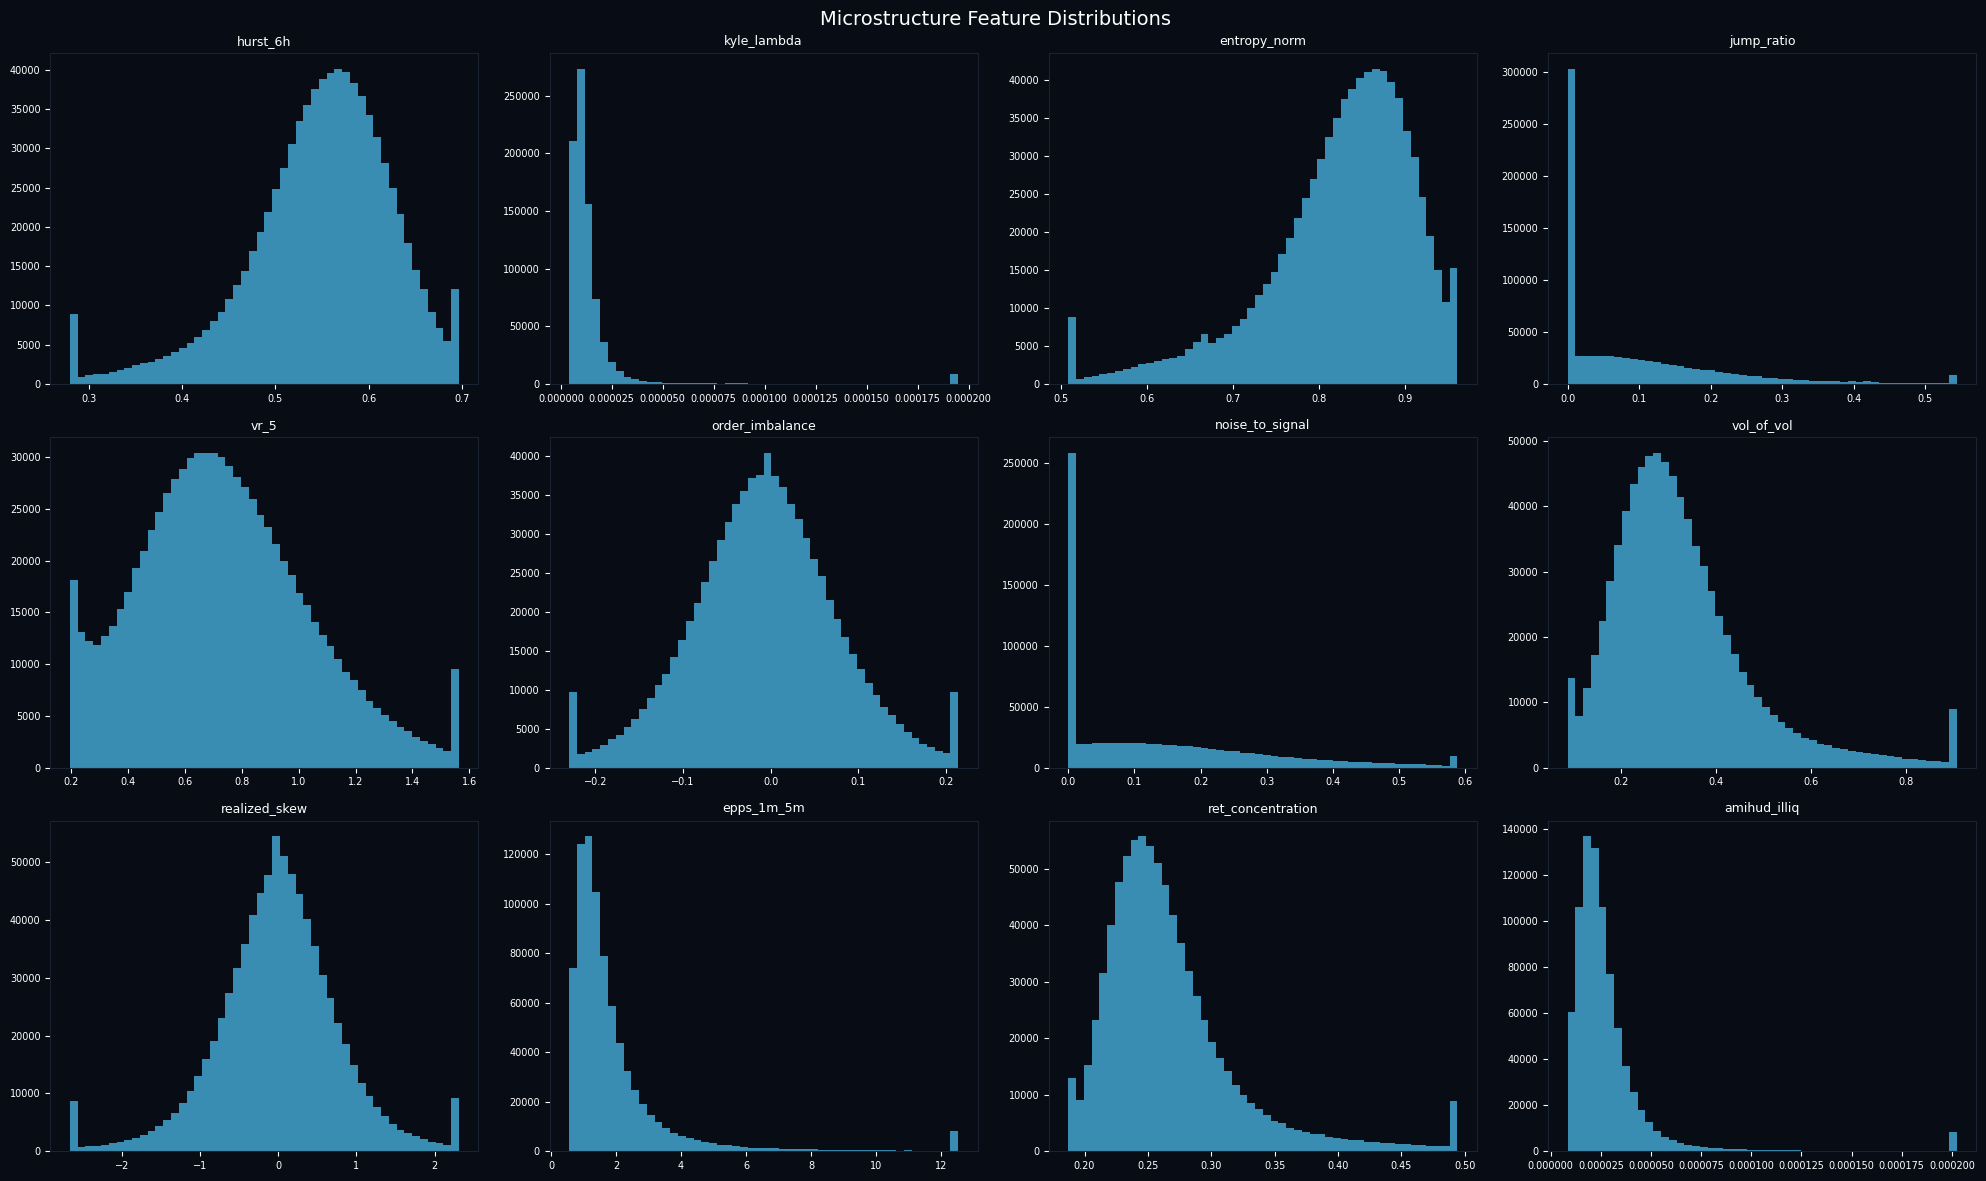

In [17]:
# Feature distributions — plot key features
key_features = ['hurst_6h', 'kyle_lambda', 'entropy_norm', 'jump_ratio',
                'vr_5', 'order_imbalance', 'noise_to_signal', 'vol_of_vol',
                'realized_skew', 'epps_1m_5m', 'ret_concentration', 'amihud_illiq']

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.patch.set_facecolor('#080c14')

for ax, feat in zip(axes.flat, key_features):
    ax.set_facecolor('#080c14')
    if feat in df_all.columns:
        vals = df_all[feat].dropna()
        # Clip outliers for visualization
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals_clipped = vals.clip(lo, hi)
        ax.hist(vals_clipped, bins=50, color='#4fc3f7', alpha=0.7, edgecolor='none')
    ax.set_title(feat, color='white', fontsize=9)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a2332')

plt.suptitle('Microstructure Feature Distributions', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

**Features computed from 1min/5min/15min OHLCV data, aggregated to 1H:**

| Category | Count | Key Features |
|----------|-------|--------------|
| Realized Vol Estimators | 6 | Parkinson, Garman-Klass, Rogers-Satchell, Yang-Zhang, range-return ratio |
| Jump Detection | 7 | RV, BV, jump ratio, jump z-stat, jump intensity/size/asymmetry |
| Order Flow | 8 | BVC buy fraction, order imbalance, Kyle's lambda, Amihud illiquidity, volume CV |
| Information Theory | 5 | Return entropy, normalized entropy, JB stat, KL proxy, vol-weighted entropy divergence |
| Fractal Analysis | 2 | Hurst (per-hour), fractal dimension (per-hour) |
| Market Efficiency | 10 | Variance ratios, runs test, autocorrelations, decay halflife, noise-to-signal |
| Tail Risk | 4 | Realized skewness/kurtosis, tail ratio, Hill estimator |
| Acceleration | 6 | Price acceleration mean/std/skew, momentum shift, return concentration, vol clustering |
| Cross-Timeframe | 6 | Epps ratios (3), info acceleration, vol-of-vol, 5m autocorrelation |
| Trailing Window | 10 | Hurst 6h, fractal 6h, VPIN 4h/12h, VR regime, RV z-score, Kyle's lambda trend, entropy regime |
| **Total** | **~64** | |